In [1]:


import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

DATA_PATH = Path("../data/diabetic_data.csv")  # Change this path if required
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

In [2]:
# Cell 2: Load the dataset

df_raw = pd.read_csv("../data/diabetic_data.csv")

print("Dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.tail())

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,?,?,13,3,3,0,0,0,530,530,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


In [3]:
# Cell 3: Basic structure

print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nData types:")
display(df_raw.dtypes.value_counts())

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nDataset information:")
df_raw.info()

Rows: 101766
Columns: 50

Data types:


str      37
int64    13
Name: count, dtype: int64


Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count

In [4]:
# Cell 4: Replace question marks with missing values

# In this dataset, '?' is used in several columns to represent missing/unknown values.
df = df_raw.replace("?", np.nan).copy()

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
    "data_type": df.dtypes.astype(str)
}).sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])

missing_summary.to_csv(OUTPUT_DIR / "missing_values_summary.csv")

,missing_count,missing_percentage,data_type
weight,98569,96.86,str
max_glu_serum,96420,94.75,str
A1Cresult,84748,83.28,str
medical_specialty,49949,49.08,str
payer_code,40256,39.56,str
race,2273,2.23,str
diag_3,1423,1.40,str
diag_2,358,0.35,str
diag_1,21,0.02,str


,count,percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


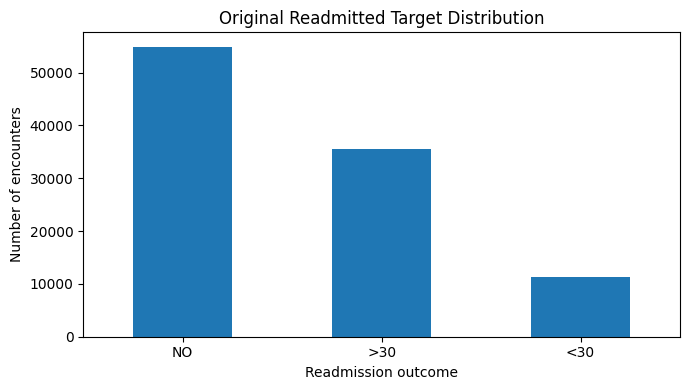

In [5]:
# Cell 5: Target variable distribution

target_counts = df["readmitted"].value_counts(dropna=False)
target_percentages = (df["readmitted"].value_counts(normalize=True, dropna=False) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

display(target_summary)

ax = target_counts.reindex(["NO", ">30", "<30"]).plot(
    kind="bar",
    figsize=(7, 4),
    title="Original Readmitted Target Distribution"
)
ax.set_xlabel("Readmission outcome")
ax.set_ylabel("Number of encounters")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

target_summary.to_csv(OUTPUT_DIR / "target_distribution.csv")

In [6]:
# Cell 6: Confirm the three-class target

expected_classes = {"NO", ">30", "<30"}
actual_classes = set(df["readmitted"].dropna().unique())

print("Actual target classes:", actual_classes)
print("Expected classes:", expected_classes)
print("All expected classes present:", expected_classes.issubset(actual_classes))

Actual target classes: {'NO', '<30', '>30'}
Expected classes: {'NO', '<30', '>30'}
All expected classes present: True


In [7]:
# Cell 7: Identifier analysis

identifier_columns = ["encounter_id", "patient_nbr"]

identifier_summary = pd.DataFrame({
    "unique_values": [df[col].nunique(dropna=False) for col in identifier_columns],
    "duplicate_values": [df[col].duplicated().sum() for col in identifier_columns]
}, index=identifier_columns)

display(identifier_summary)

print("Exact duplicate rows:", df.duplicated().sum())
print("Unique patients:", df["patient_nbr"].nunique())
print("Patients with more than one encounter:",
      (df["patient_nbr"].value_counts() > 1).sum())

patient_encounter_counts = df["patient_nbr"].value_counts()
display(patient_encounter_counts.describe())

,unique_values,duplicate_values
encounter_id,101766,0
patient_nbr,71518,30248


Exact duplicate rows: 0
Unique patients: 71518
Patients with more than one encounter: 16773


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: count, dtype: float64

In [8]:
# Cell 8: Duplicate investigation

exact_duplicate_rows = df.duplicated().sum()
duplicate_encounter_ids = df["encounter_id"].duplicated().sum()

print("Exact duplicate rows:", exact_duplicate_rows)
print("Repeated encounter_id values:", duplicate_encounter_ids)

# Repeated patient_nbr values are not automatically duplicates.
# They may represent separate hospital encounters.
repeated_patient_records = df[df["patient_nbr"].duplicated(keep=False)].sort_values("patient_nbr")
display(repeated_patient_records[["patient_nbr", "encounter_id", "readmitted"]].head(20))

Exact duplicate rows: 0
Repeated encounter_id values: 0


,patient_nbr,encounter_id,readmitted
4780,135,26264286,>30
4267,135,24437208,<30
5953,1152,30180318,>30
23623,1152,80742510,>30
14180,1152,55533660,>30
24642,1152,83281464,NO
1164,1152,8380170,>30
19914,1314,70601076,NO
19765,1314,70190028,<30
15848,1314,60254142,>30
